# Nachrichtengröße Evaluation für OmniSphinx und native Mix-Formate

Dieses Notebook untersucht den Goodput verschiedener Mix-Format-Varianten.
Die betrachteten Varianten umfassen OmniSphinx in unterschiedlichen Emulationsmodi sowie native Sphinx-, ImprovingSphinx-, PolySphinx-, EROR- und MultiSphinx-Formate.
Für alle Analysen setzen wir die Pfadlänge auf $r = 5$ und verwenden die in der Implementierung hinterlegte Sicherheitsparameterisierung mit $\kappa = 128$ Bits.


## In diesem Notebook enthalten:

1. **Beta-Länge vs. Goodput**  
   * Fixierte Payload-Länge: 512 Bytes.  
   * Variiere die Beta-Länge (nur gültige Werte) und berechne Goodput sowie Paketgröße für jede Variante.  
   * Visualisiere Goodput in Abhängigkeit der Beta-Länge.

2. **Payload-Größe vs. Goodput**  
   * Fixiere die Header-Größen (Alpha, Beta, Gamma) pro Variante.  
   * Variiere die Payload-Größe von 0 bis 4096 Bytes und berechne den Goodput.  
   * Visualisiere den Goodput in Abhängigkeit der Payload-Größe.

Für native Varianten orientieren wir uns an den Referenzformeln aus der Literatur.


In [22]:
import math
from dataclasses import dataclass
from typing import Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')


In [23]:
# Global parameters


BITS_PER_BYTE = 8
KAPPA_BITS = 16 * BITS_PER_BYTE
KAPPA_BYTES = KAPPA_BITS // BITS_PER_BYTE
ALPHA_BITS = 2 * KAPPA_BITS
GAMMA_BITS = KAPPA_BITS
PATH_LENGTH = 5
SPHINX_PATH_LENGTH = 10



# Helper utilities


def ceil_div(a: int, b: int) -> int:
    """Return the ceiling of ``a / b`` for positive integers."""

    return -(-a // b)


def bits_to_full_bytes(bit_length: int) -> int:
    """Convert ``bit_length`` to the smallest integer number of bytes."""

    return ceil_div(bit_length, BITS_PER_BYTE)


def load_bits(length_bytes: int, *, prefix_bytes: int = 3) -> int:
    """Bit length of a LOAD instruction including its inlined data."""

    return bytes_to_bits(length_bytes) + prefix_bytes * BITS_PER_BYTE

def store_bytes_bits(length_bytes: int) -> int:
    """Bit length of a STORE_BYTES instruction for the given slice length."""

    if length_bytes <= 0xFF:
        return 4 * BITS_PER_BYTE
    if length_bytes <= 0xFFFF:
        return 5 * BITS_PER_BYTE
    if length_bytes <= 0xFFFFFF:
        return 6 * BITS_PER_BYTE
    return 7 * BITS_PER_BYTE

def bytes_to_bits(num_bytes: int) -> int:
    """Convert ``num_bytes`` to bits."""

    return num_bytes * BITS_PER_BYTE


def packet_size_bits(payload_bits: int, beta_bits: int) -> int:
    """Total packet size for the fixed alpha and gamma headers."""

    return ALPHA_BITS + GAMMA_BITS + beta_bits + payload_bits


def goodput(payload_bits: int, total_bits: int, replication_factor: int = 1) -> float:
    """Goodput defined as the ratio of delivered payload bits to transmitted bits."""

    if total_bits == 0:
        return 0.0
    return (payload_bits * replication_factor) / total_bits


def packet_total_bits(payload_bits: int, beta_bits: int) -> int:
    """Alias for :func:`packet_size_bits` for semantic clarity."""

    return packet_size_bits(payload_bits, beta_bits)


def sender_cost_bits(payload_bits: int, beta_bits: int) -> int:
    """Bits a Sender must transmit for a packet with the given payload and β."""

    return packet_total_bits(payload_bits, beta_bits)


def sender_cost_bytes(payload_bits: int, beta_bits: int) -> int:
    """Sender costs converted to whole bytes."""

    return bits_to_full_bytes(sender_cost_bits(payload_bits, beta_bits))


def sum_of_outputs_bits(payload_bits: int, beta_bits: int, path_length: int) -> int:
    """Total number of bits emitted into the network along all hops."""

    return path_length * packet_total_bits(payload_bits, beta_bits)


def sum_of_outputs_bytes(payload_bits: int, beta_bits: int, path_length: int) -> int:
    """Sum of network outputs expressed in whole bytes."""

    return bits_to_full_bytes(sum_of_outputs_bits(payload_bits, beta_bits, path_length))


def delivered_payload_bits(payload_bits: int, replication_factor: int = 1) -> int:
    """Effective payload bits delivered to recipients."""

    return payload_bits * replication_factor


def network_goodput_ratio(
    payload_bits: int,
    beta_bits: int,
    path_length: int,
    *,
    replication_factor: int = 1,
) -> float:
    """Ratio of delivered payload bits to all network outputs."""

    outputs_bits = sum_of_outputs_bits(payload_bits, beta_bits, path_length)
    delivered_bits = delivered_payload_bits(payload_bits, replication_factor)
    if outputs_bits == 0:
        return 0.0
    return delivered_bits / outputs_bits


def network_cost_ratio(
    payload_bits: int,
    beta_bits: int,
    path_length: int,
    *,
    replication_factor: int = 1,
):
    """Ratio of network outputs to delivered payload bits."""

    delivered_bits = delivered_payload_bits(payload_bits, replication_factor)
    if delivered_bits == 0:
        return np.nan
    outputs_bits = sum_of_outputs_bits(payload_bits, beta_bits, path_length)
    return outputs_bits / delivered_bits

In [24]:
# FOR POLYSPHINX INSTRUCTIONS
# Instruction block sizes for OmniSphinx

def relay_instruction_bits(kappa_bits: int = KAPPA_BITS) -> int:
    """Length of a PolySphinx relay instruction block (including prefix)."""

    load_sigma = kappa_bits + 3 * BITS_PER_BYTE
    encrypt = 4 * BITS_PER_BYTE
    load_next_hop = kappa_bits + 3 * BITS_PER_BYTE
    forward = 2 * BITS_PER_BYTE
    gamma = kappa_bits
    return load_sigma + encrypt + load_next_hop + forward + gamma + BITS_PER_BYTE


def exit_instruction_bits(p: int, remaining_hops: int, *, kappa_bits: int = KAPPA_BITS) -> int:
    """Length of the PolySphinx exit instruction block (including prefix)."""

    log2p = math.ceil(math.log2(p))
    path_selector_bits = log2p * (remaining_hops + 1)

    load_seed = kappa_bits + 3 * BITS_PER_BYTE
    load_path = path_selector_bits + 3 * BITS_PER_BYTE
    load_recipient = kappa_bits + 3 * BITS_PER_BYTE
    hash_seed = 3 * BITS_PER_BYTE
    append_seed = 4 * BITS_PER_BYTE
    loop_setup = 3 * BITS_PER_BYTE
    loop_body = (
        4 * BITS_PER_BYTE  # load path fragment
        + 4 * BITS_PER_BYTE  # concatenate path piece
        + 3 * BITS_PER_BYTE  # compute hash
        + 3 * BITS_PER_BYTE  # xor with seed
        + 4 * BITS_PER_BYTE  # append recipient data
    )
    decrypt_loop = 3 * BITS_PER_BYTE
    decrypt_body = 4 * BITS_PER_BYTE + 4 * BITS_PER_BYTE
    forward = 2 * BITS_PER_BYTE

    raw_bits = (
        load_seed
        + load_path
        + load_recipient
        + hash_seed
        + append_seed
        + loop_setup
        + loop_body
        + decrypt_loop
        + decrypt_body
        + forward
    )
    return raw_bits + BITS_PER_BYTE


def replication_instruction_bits(p: int, beta_post_bits: int, *, kappa_bits: int = KAPPA_BITS) -> int:
    """Length of the replication instruction block used by OmniSphinx."""


    subheader_bits = p * (5 * kappa_bits + beta_post_bits)
    load_subheaders = subheader_bits + 3 * BITS_PER_BYTE
    loop_setup = 3 * BITS_PER_BYTE
    loop_body = (
        4 * BITS_PER_BYTE  # GET_NEXT_HOP
        + 4 * BITS_PER_BYTE  # GET_KEY
        + 4 * BITS_PER_BYTE  # GET_ALPHA
        + 4 * BITS_PER_BYTE  # GET_GAMMA
        + 4 * BITS_PER_BYTE  # GET_BETA
        + 4 * BITS_PER_BYTE  # ENCRYPT
        + 2 * BITS_PER_BYTE  # FORWARD
    )
    return load_subheaders + loop_setup + loop_body + BITS_PER_BYTE

In [ ]:
# For Improving Sphinx Instructions

def improving_sphinx_instruction_bits(*, mac_bytes: int = KAPPA_BITS, next_hop_bytes: int = KAPPA_BITS) -> int:
    """Length of an ImprovingSphinx instruction block in bits."""

    total = 0
    total += load_bits(mac_bytes)
    total += 4 * BITS_PER_BYTE  # concat shared secret with MAC salt
    total += 3 * BITS_PER_BYTE  # hash for MAC key derivation
    total += 4 * BITS_PER_BYTE  # MAC computation
    total += 3 * BITS_PER_BYTE  # MAC verification
    total += 4 * BITS_PER_BYTE  # concat shared secret with payload salt
    total += 3 * BITS_PER_BYTE  # hash for payload key derivation
    total += 4 * BITS_PER_BYTE  # payload decryption
    total += load_bits(next_hop_bytes)
    total += 2 * BITS_PER_BYTE  # forward instruction
    total += BITS_PER_BYTE      # stop instruction
    return total

In [26]:
# For EROR Instructions
def eror_instruction_bits(*, mac_bytes: int = KAPPA_BYTES, next_hop_bytes: int = KAPPA_BYTES, forward_payload_len: int = KAPPA_BYTES, backward_cipher_len: int = KAPPA_BYTES, backward_mac_len: int = KAPPA_BYTES,) -> int:
    """Length of an EROR instruction block in bits."""

    total = 0
    total += store_bytes_bits(forward_payload_len)
    total += store_bytes_bits(backward_cipher_len)
    total += store_bytes_bits(backward_mac_len)
    total += 4 * BITS_PER_BYTE  # concat shared secret with SKE salt
    total += 3 * BITS_PER_BYTE  # hash to derive SKE key
    total += load_bits(mac_bytes)
    total += 4 * BITS_PER_BYTE  # forward MAC verification
    total += 3 * BITS_PER_BYTE  # compare MACs
    total += 4 * BITS_PER_BYTE  # decrypt forward payload
    total += 4 * BITS_PER_BYTE  # decrypt backward ciphertext
    total += 4 * BITS_PER_BYTE  # concat shared secret with PRF salt
    total += 3 * BITS_PER_BYTE  # hash to derive PRF key
    total += 4 * BITS_PER_BYTE  # PRG generation
    total += 4 * BITS_PER_BYTE  # XOR backward MAC
    total += 4 * BITS_PER_BYTE  # concatenate backward payload
    total += 4 * BITS_PER_BYTE  # append forward payload
    total += load_bits(next_hop_bytes)
    total += 2 * BITS_PER_BYTE  # forward instruction
    total += BITS_PER_BYTE      # stop instruction
    return total

In [27]:
# FOR SPHINX INSTRUCTIONS
def sphinx_instruction_bits(kappa_bits: int = KAPPA_BITS) -> int:
    """Length of a single OmniSphinx instruction block in bits."""

    forward_bits = BITS_PER_BYTE + BITS_PER_BYTE + kappa_bits
    return (
        3 * BITS_PER_BYTE  # concatWithByteValue
        + 3 * BITS_PER_BYTE  # hash
        + 4 * BITS_PER_BYTE  # decrypt
        + forward_bits
    )

In [28]:
# FOR MULTISPHINX INSTRUCTIONS
def multi_relay_instruction_bits(*, kappa_bits: int = KAPPA_BITS) -> int:
    """Length of a MultiSphinx solo instruction block (including prefix)."""

    load_payload_mac = kappa_bits + 3 * BITS_PER_BYTE
    load_next_hop = kappa_bits + 3 * BITS_PER_BYTE
    concat_ops = 2 * 4 * BITS_PER_BYTE
    mac_verify_hash = (3 + 3 + 3) * BITS_PER_BYTE
    decrypt_bits = 4 * BITS_PER_BYTE
    forward_bits = 2 * BITS_PER_BYTE
    return (
        load_payload_mac
        + load_next_hop
        + concat_ops
        + mac_verify_hash
        + decrypt_bits
        + forward_bits
        + BITS_PER_BYTE
    )


def multi_replication_instruction_bits(p: int, *, kappa_bits: int = KAPPA_BITS,) -> int:
    """Length of the MultiSphinx replication block based on the Java presets."""

    load_payload_mac = kappa_bits + 3 * BITS_PER_BYTE
    concat_ops = 2 * 4 * BITS_PER_BYTE
    mac_verify_hash = (3 + 3 + 3) * BITS_PER_BYTE
    decrypt_bits = 4 * BITS_PER_BYTE
    length_loads = 2 * (BITS_PER_BYTE + 3 * BITS_PER_BYTE)
    load_next_hops = p * kappa_bits + 3 * BITS_PER_BYTE
    loop_setup = 3 * BITS_PER_BYTE
    iter_bits = (4  + 4 + 4 + 4 + 3 + 4 + 4 + 4 + 2) * BITS_PER_BYTE # STORE_MULTIPLE + STORE_MULTIPLE + storeBytes + concate + hash+ prg + concate + store
    return (
        load_payload_mac
        + concat_ops
        + mac_verify_hash
        + decrypt_bits
        + length_loads
        + load_next_hops
        + loop_setup
        + iter_bits
        + BITS_PER_BYTE
    )


In [29]:
# POLYSPHINX
# Beta length formulas


def omni_poly_beta_post_bits(p: int, *, remaining_hops: int, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length after replication for OmniSphinx emulating PolySphinx."""

    return remaining_hops * relay_instruction_bits(kappa_bits) + exit_instruction_bits(p, remaining_hops, kappa_bits=kappa_bits)


def omni_poly_beta_bits(p: int, *, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length before replication for OmniSphinx emulating PolySphinx."""

    beta_post_bits = omni_poly_beta_post_bits(p, remaining_hops=path_length - 1, kappa_bits=kappa_bits)
    replication_bits = replication_instruction_bits(p, beta_post_bits, kappa_bits=kappa_bits)
    relay_overhead = (path_length - 1) * relay_instruction_bits(kappa_bits)
    return replication_bits + relay_overhead + kappa_bits + BITS_PER_BYTE


def native_poly_beta_post_bits(p: int, *, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Post-replication beta length for native PolySphinx."""

    return path_length * (BITS_PER_BYTE + 3 * kappa_bits) + kappa_bits + path_length * math.ceil(math.log2(p))


def native_poly_beta_bits(p: int, *, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Pre-replication beta length for native PolySphinx."""

    beta_post_bits = native_poly_beta_post_bits(p, path_length=path_length, kappa_bits=kappa_bits)
    return (path_length - 1) * (BITS_PER_BYTE + 3 * kappa_bits) + BITS_PER_BYTE + p * (5 * kappa_bits + beta_post_bits)

In [ ]:
#SPHINX 

def native_sphinx_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length for native Sphinx packets."""

    return path_length * 2 * (2 * kappa_bits + BITS_PER_BYTE) # 2 Times Path Length, since in PolySphinx each Segment (from Sender to Replication and from Replication to Exit) has pathlength hops


def omni_sphinx_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length for OmniSphinx emulating the native Sphinx format."""

    instr_bits = sphinx_instruction_bits(kappa_bits)
    return path_length * 2 * (instr_bits + kappa_bits)

In [31]:
# EROR
def native_eror_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length for native EROR packets."""
    return path_length * 2 * (2 * kappa_bits + BITS_PER_BYTE + BITS_PER_BYTE) # 2 Times Path Length, since in PolySphinx each Segment (from Sender to Replication and from Replication to Exit) has pathlength hops



def omni_eror_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    kappa_bytes = kappa_bits // BITS_PER_BYTE
    instr_bits = eror_instruction_bits(
        mac_bytes=kappa_bytes,
        next_hop_bytes=kappa_bytes,
        forward_payload_len=kappa_bytes,
        backward_cipher_len=kappa_bytes,
        backward_mac_len=kappa_bytes,
    )
    return path_length * instr_bits

In [ ]:
#Improving Sphinx
def native_improving_sphinx_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
    """Beta length for native ImprovingSphinx packets."""
    return path_length * 2 * (2 * kappa_bits + BITS_PER_BYTE) 

def omni_improving_sphinx_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS) -> int:
	
    kappa_bytes = kappa_bits // BITS_PER_BYTE
    instr_bits = improving_sphinx_instruction_bits(mac_bytes=kappa_bytes, next_hop_bytes=kappa_bytes)
    return path_length * 2 * (instr_bits + KAPPA_BITS)

In [33]:
#FOR MULTISPHINX
def omni_multi_beta_bits(p: int, *, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS,) -> int:
    """Beta length before replication for OmniSphinx emulating MultiSphinx."""
    instr_bits_relay = multi_relay_instruction_bits()
    instr_bits_replication = multi_replication_instruction_bits(p)
    return (instr_bits_relay + kappa_bits + BITS_PER_BYTE) * ((2*path_length) - 1) + (instr_bits_replication + kappa_bits + BITS_PER_BYTE) 

def native_multi_beta_bits(*, path_length: int = PATH_LENGTH, kappa_bits: int = KAPPA_BITS,) -> int:
    """beta length for native MultiSphinx."""

    return path_length * 2 * (2 * kappa_bits + BITS_PER_BYTE) # 2 Times Path Length, since in PolySphinx each Segment (from Sender to Replication and from Replication to Exit) has pathlength hops



In [34]:

# Variant description



@dataclass(frozen=True)
class Variant:
    name: str
    beta_min: int
    kind: str
    p: Optional[int] = None
    path_length: int = PATH_LENGTH
    family: str = "Sphinx"


variants: Dict[str, Variant] = {
    "omni_sphinx": Variant(
        "OmniSphinx – Sphinx (emuliert)",
        omni_sphinx_beta_bits(),
        "omni",
        path_length=SPHINX_PATH_LENGTH,
        family="Sphinx",
    ),
	"omni_improving_sphinx": Variant(
        "Improving Sphinx (emuliert)",
        omni_improving_sphinx_beta_bits(),
        "omni",
        path_length=PATH_LENGTH,
        family="ImprovingSphinx",
    ),
    "omni_eror": Variant(
        "EROR (emuliert)",
        omni_eror_beta_bits(),
        "omni",
        path_length=PATH_LENGTH,
        family="EROR",
    ),
    "omni_poly_p3": Variant(
        "OmniSphinx – Poly (p=3)",
        omni_poly_beta_bits(3),
        "omni",
        3,
        family="PolySphinx",
    ),
    "omni_poly_p5": Variant(
        "OmniSphinx – Poly (p=5)",
        omni_poly_beta_bits(5),
        "omni",
        5,
        family="PolySphinx",
    ),
    "omni_poly_p10": Variant(
        "OmniSphinx – Poly (p=10)",
        omni_poly_beta_bits(10),
        "omni",
        10,
        family="PolySphinx",
    ),
    "omni_multi_p3": Variant(
        "OmniSphinx  Multi (p=3)",
        omni_multi_beta_bits(3),
        "omni",
        3,
        family="MultiSphinx",
    ),
    "omni_multi_p5": Variant(
        "OmniSphinx – Multi (p=5)",
        omni_multi_beta_bits(5),
        "omni",
        5,
        family="MultiSphinx",
    ),
    "omni_multi_p10": Variant(
        "OmniSphinx - Multi (p=10)",
        omni_multi_beta_bits(10),
        "omni",
        10,
        family="MultiSphinx",
    ),
    "sphinx_native": Variant(
        "Sphinx (nativ)",
        native_sphinx_beta_bits(),
        "native",
        path_length=SPHINX_PATH_LENGTH,
        family="Sphinx",
    ),
    "improving_sphinx_native": Variant(
        "Improving Sphinx (nativ)",
        native_improving_sphinx_beta_bits(),
        "native",
        path_length=PATH_LENGTH,
        family="ImprovingSphinx",
    ),
    "eror_native": Variant(
        "EROR (nativ)",
        native_eror_beta_bits(),
        "native",
        path_length=PATH_LENGTH,
        family="EROR",
    ),
    "poly_native_p3": Variant(
        "PolySphinx (nativ, p=3)",
        native_poly_beta_bits(3),
        "native",
        3,
        family="PolySphinx",
    ),
    "poly_native_p5": Variant(
        "PolySphinx (nativ, p=5)",
        native_poly_beta_bits(5),
        "native",
        5,
        family="PolySphinx",
    ),
    "poly_native_p10": Variant(
        "PolySphinx (nativ, p=10)",
        native_poly_beta_bits(10),
        "native",
        10,
        family="PolySphinx",
    ),
    "multi_native_p3": Variant(
        "MultiSphinx (nativ, p=3)",
        native_multi_beta_bits(),
        "native",
        3,
        family="MultiSphinx",
    ),
    "multi_native_p5": Variant(
        "MultiSphinx (nativ, p=5)",
        native_multi_beta_bits(),
        "native",
        5,
        family="MultiSphinx",
    ),
    "multi_native_p10": Variant(
        "MultiSphinx (nativ, p=10)",
        native_multi_beta_bits(),
        "native",
        10,
        family="MultiSphinx",
    ),
}

summary_df = pd.DataFrame(
    {
        "Variante": [v.name for v in variants.values()],
        "βₘᵢₙ [B]": [bits_to_full_bytes(v.beta_min) for v in variants.values()],
        "Replikationsfaktor": [v.p if v.p is not None else 1 for v in variants.values()],
    }
)
summary_df


,Variante,βₘᵢₙ [B],Replikationsfaktor
0,OmniSphinx – Sphinx (emuliert),450,1
1,Improving Sphinx (emuliert),330,1
2,EROR (emuliert),490,1
3,OmniSphinx – Poly (p=3),1519,3
4,OmniSphinx – Poly (p=5),2339,5
5,OmniSphinx – Poly (p=10),4389,10
6,OmniSphinx Multi (p=3),864,3
7,OmniSphinx – Multi (p=5),896,5
8,OmniSphinx - Multi (p=10),976,10
9,Sphinx (nativ),330,1


##  β-Länge vs. Goodput

Wir untersuchen, wie sich die wählbare Größe von β auf die Goodput-Effizienz der unterschiedlichen OmniSphinx-Varianten auswirkt. Die Payload ist auf 512 Bytes fixiert, während β über einem zulässigen Bereich variiert. Für β-Werte unterhalb der jeweiligen Mindestgröße wird kein Punkt dargestellt.


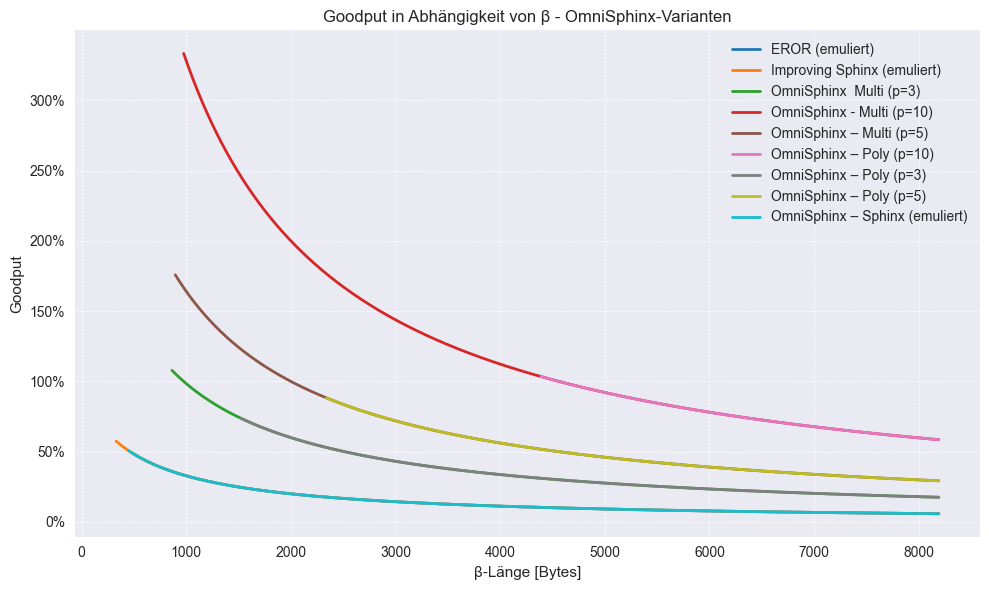

In [35]:
PAYLOAD_TASK1_BYTES = 512
BETA_MAX_BYTES = 8192
BETA_STEP_BYTES = 1

payload_bits_task1 = bytes_to_bits(PAYLOAD_TASK1_BYTES)
omni_variants = {key: variant for key, variant in variants.items() if variant.kind == "omni"}

if not omni_variants:
    raise ValueError("Es stehen keine OmniSphinx-Varianten zur Verfügung.")

beta_goodput_records = []

for key, variant in omni_variants.items():
    replication_factor = variant.p if variant.p is not None else 1
    beta_min_bits = variant.beta_min
    beta_min_bytes = bits_to_full_bytes(beta_min_bits)
    if beta_min_bytes > BETA_MAX_BYTES:
        raise ValueError("β-Minimum {beta_min_bytes} B der Variante {variant.name} überschreitet BETA_MAX_BYTES")
    beta_range_bytes = np.arange(
        beta_min_bytes,
        BETA_MAX_BYTES + BETA_STEP_BYTES,
        BETA_STEP_BYTES,
    )

    valid_beta_bytes = []
    goodput_values = []

    for beta_bytes in beta_range_bytes:
        beta_bits = bytes_to_bits(beta_bytes)
        if beta_bits < beta_min_bits:
            continue
        total_bits = packet_size_bits(payload_bits_task1, beta_bits)
        gp = goodput(payload_bits_task1, total_bits, replication_factor)
        valid_beta_bytes.append(beta_bytes)
        goodput_values.append(gp)

    if not valid_beta_bytes:
        continue

    beta_goodput_records.append(
        pd.DataFrame(
            {
                "Variante": variant.name,
                "β [B]": valid_beta_bytes,
                "Goodput": goodput_values,
            }
        )
    )

if not beta_goodput_records:
    raise ValueError("Es stehen keine gültigen β-Werte für OmniSphinx zur Verfügung.")

beta_goodput_df = (
    pd.concat(beta_goodput_records, ignore_index=True)
    .sort_values(["Variante", "β [B]"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
color_map = dict(
    zip(
        beta_goodput_df["Variante"].unique(),
        plt.cm.tab10(np.linspace(0, 1, beta_goodput_df["Variante"].nunique())),
    )
)

for variant_name, group in beta_goodput_df.groupby("Variante"):
    sorted_group = group.sort_values("β [B]")
    ax.plot(
        sorted_group["β [B]"],
        sorted_group["Goodput"],
        label=variant_name,
        color=color_map[variant_name],
        linewidth=2,
    )

ax.set_title("Goodput in Abhängigkeit von β - OmniSphinx-Varianten")
ax.set_xlabel("β-Länge [Bytes]")
ax.set_ylabel("Goodput")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()



## Aufgabe 2: Payload-Größe vs. Goodput

Hier halten wir die Kopfzeilen-Größen (α, β, γ) für jede Variante fest und variieren die Payload von 0 B bis 4096 B.


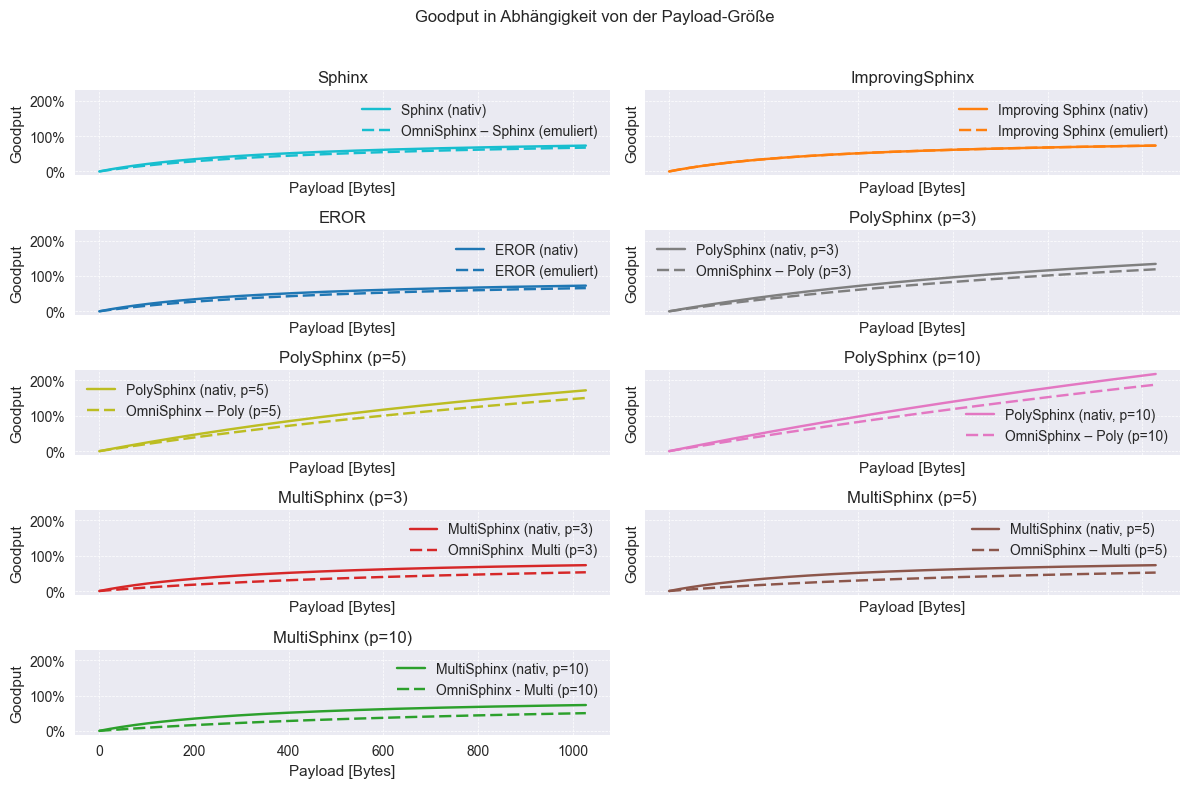

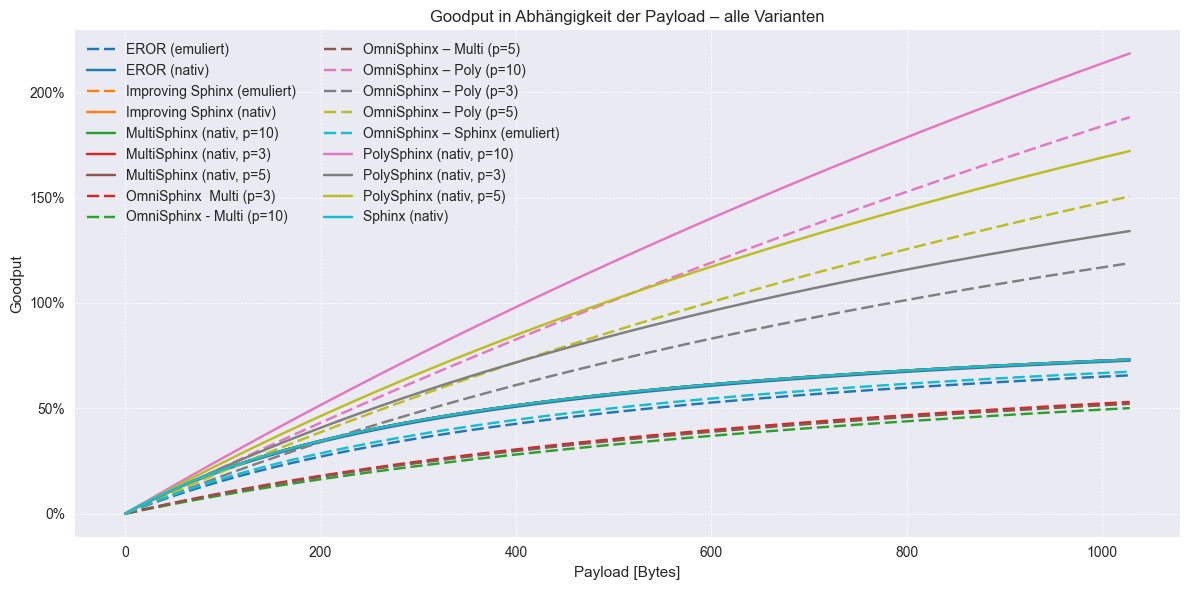

In [36]:
PAYLOAD_MAX_BYTES = 1028
PAYLOAD_STEP_BYTES = 1

payload_range_bytes = np.arange(0, PAYLOAD_MAX_BYTES + PAYLOAD_STEP_BYTES, PAYLOAD_STEP_BYTES)

payload_goodput_records = []
variant_families = []
color_group_map = {
    "omni_sphinx": "Sphinx",
    "sphinx_native": "Sphinx",
    "improving_sphinx_native": "ImprovingSphinx",
    "eror_native": "EROR",
    "omni_poly_p3": "PolySphinx (p=3)",
    "poly_native_p3": "PolySphinx (p=3)",
    "omni_poly_p5": "PolySphinx (p=5)",
    "poly_native_p5": "PolySphinx (p=5)",
    "omni_poly_p10": "PolySphinx (p=10)",
    "poly_native_p10": "PolySphinx (p=10)",
    "omni_multi_p3": "MultiSphinx (p=3)",
    "multi_native_p3": "MultiSphinx (p=3)",
    "omni_multi_p5": "MultiSphinx (p=5)",
    "multi_native_p5": "MultiSphinx (p=5)",
    "omni_multi_p10": "MultiSphinx (p=10)",
    "multi_native_p10": "MultiSphinx (p=10)",
}

for key, variant in variants.items():
    if variant.family == "MultiSphinx":
        replication_factor = 1
    else:
        replication_factor = variant.p if variant.p is not None else 1
    beta_bits = variant.beta_min
    goodput_values = []

    for payload_bytes in payload_range_bytes:
        payload_bits = bytes_to_bits(payload_bytes)
        total_bits = packet_size_bits(payload_bits, beta_bits)
        gp = goodput(payload_bits, total_bits, replication_factor)
        goodput_values.append(gp)

    if variant.family == "Sphinx":
        family = "Sphinx"
    elif variant.p is None:
        family = variant.family
    else:
        family = f"{variant.family} (p={variant.p})"
    if family not in variant_families:
        variant_families.append(family)

    color_group = color_group_map.get(key, family)

    payload_goodput_records.append(
        pd.DataFrame(
            {
                "Variante": variant.name,
                "Variantenfamilie": family,
                "Kind": variant.kind,
                "Farbgruppe": color_group,
                "Payload [B]": payload_range_bytes,
                "Goodput": goodput_values,
            }
        )
    )

payload_goodput_df = (
    pd.concat(payload_goodput_records, ignore_index=True)
    .sort_values(["Variantenfamilie", "Kind", "Payload [B]"])
    .reset_index(drop=True)
)

line_styles = {"native": "-", "omni": (0, (5, 2))}

group_colors = dict(
    zip(
        payload_goodput_df["Farbgruppe"].unique(),
        plt.cm.tab10(np.linspace(0, 1, payload_goodput_df["Farbgruppe"].nunique())),
    )
)

variant_colors = {}
for variant_name, color_group in (payload_goodput_df[["Variante", "Farbgruppe"]].drop_duplicates().itertuples(index=False)):
    variant_colors[variant_name] = group_colors[color_group]


ncols = 2
nrows = math.ceil(len(variant_families) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, family in zip(axes, variant_families):
    subset = payload_goodput_df[payload_goodput_df["Variantenfamilie"] == family]
    for kind, group in subset.groupby("Kind"):
        sorted_group = group.sort_values("Payload [B]")
        ax.plot(
            sorted_group["Payload [B]"],
            sorted_group["Goodput"],
            label=sorted_group["Variante"].iloc[0],
            color=variant_colors[sorted_group["Variante"].iloc[0]],
            linestyle=line_styles.get(kind, "-"),
        )
    ax.set_title(family)
    ax.set_xlabel("Payload [Bytes]")
    ax.set_ylabel("Goodput")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax.legend()

for ax in axes[len(variant_families):]:
    ax.set_visible(False)

fig.suptitle("Goodput in Abhängigkeit von der Payload-Größe")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Gesamtansicht aller Varianten
fig, ax = plt.subplots(figsize=(12, 6))
for variant_name, group in payload_goodput_df.groupby("Variante"):
    sorted_group = group.sort_values("Payload [B]")
    ax.plot(
        sorted_group["Payload [B]"],
        sorted_group["Goodput"],
        label=variant_name,
        color=variant_colors[variant_name],
        linestyle=line_styles.get(sorted_group["Kind"].iloc[0], "-"),
    )

ax.set_title("Goodput in Abhängigkeit der Payload – alle Varianten")
ax.set_xlabel("Payload [Bytes]")
ax.set_ylabel("Goodput")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()


## Unicast-Analyse: Overhead und Netzwerkkosten

Die folgenden Auswertungen betrachten ausschließlich die Unicast-Varianten **OmniSphinx – Sphinx (emuliert)** und **Sphinx (nativ)**. Neben der bestehenden Tabelle der β-Größen ergänzen wir Visualisierungen der Senderkosten sowie der Netzwerkkosten (Summe aller Outputs) und des daraus resultierenden Netzwerk-Goodputs.


In [37]:
from IPython.display import display

# Parameter
payload_ref_bytes = 100
payload_ref_bits = bytes_to_bits(payload_ref_bytes)

unicast_keys = ["omni_sphinx", "sphinx_native"]
unicast_variants = {key: variants[key] for key in unicast_keys if key in variants}

if len(unicast_variants) != len(unicast_keys):
    missing = sorted(set(unicast_keys) - set(unicast_variants.keys()))
    raise ValueError(f"Fehlende Unicast-Varianten: {missing}")


unicast_records = []
for key in unicast_keys:
    variant = unicast_variants[key]
    beta_bits = variant.beta_min
    total_bits = packet_total_bits(payload_ref_bits, beta_bits)
    total_bytes = bits_to_full_bytes(total_bits)
    outputs_bits = sum_of_outputs_bits(payload_ref_bits, beta_bits, variant.path_length)
    outputs_bytes = bits_to_full_bytes(outputs_bits)
    network_goodput = network_goodput_ratio(payload_ref_bits, beta_bits, variant.path_length)
    network_cost = network_cost_ratio(payload_ref_bits, beta_bits, variant.path_length)
    unicast_records.append(
        {
            "Variante": variant.name,
            "β [B]": bits_to_full_bytes(beta_bits),
            "Payload [B]": payload_ref_bytes,
            "Senderkosten [B]": total_bytes,
            "Summe Outputs [B]": outputs_bytes,
            "Netzwerk-Goodput": network_goodput,
            "Netzwerkkosten": network_cost,
            "Pfadlänge": variant.path_length,
        }
    )

unicast_metrics_df = pd.DataFrame(unicast_records)

# Payload-abhängige Kennzahlen für die Unicast-Varianten
unicast_payload_records = []
for key in unicast_keys:
    variant = unicast_variants[key]
    for payload_bytes in payload_range_bytes:
        payload_bits = bytes_to_bits(payload_bytes)
        beta_bits = variant.beta_min
        unicast_payload_records.append(
            {
                "Variante": variant.name,
                "Payload [B]": payload_bytes,
                "Senderkosten [B]": sender_cost_bytes(payload_bits, beta_bits),
                "Summe Outputs [B]": sum_of_outputs_bytes(payload_bits, beta_bits, variant.path_length),
                "Netzwerk-Goodput": network_goodput_ratio(payload_bits, beta_bits, variant.path_length),
                "Netzwerkkosten": network_cost_ratio(payload_bits, beta_bits, variant.path_length),
            }
        )

unicast_payload_metrics_df = (
    pd.DataFrame(unicast_payload_records)
    .sort_values(["Variante", "Payload [B]"])
    .reset_index(drop=True)
)

# Farbzuordnung aus den globalen Variantenfarben ableiten
unicast_palette = plt.cm.tab10(np.linspace(0, 1, len(unicast_variants)))
unicast_color_map = {
	variant.name: color
    for variant, color in zip(unicast_variants.values(), unicast_palette)
}
linestyle_defaults = globals().get("line_styles", {"native": "-", "omni": (0, (5, 2))})
unicast_linestyle_map = {
	variant.name: linestyle_defaults.get(variant.kind, "-")
	for variant in unicast_variants.values()
}
display(unicast_metrics_df)

,Variante,β [B],Payload [B],Senderkosten [B],Summe Outputs [B],Netzwerk-Goodput,Netzwerkkosten,Pfadlänge
0,OmniSphinx – Sphinx (emuliert),450,100,598,5980,0.016722,59.8,10
1,Sphinx (nativ),330,100,478,4780,0.020921,47.8,10


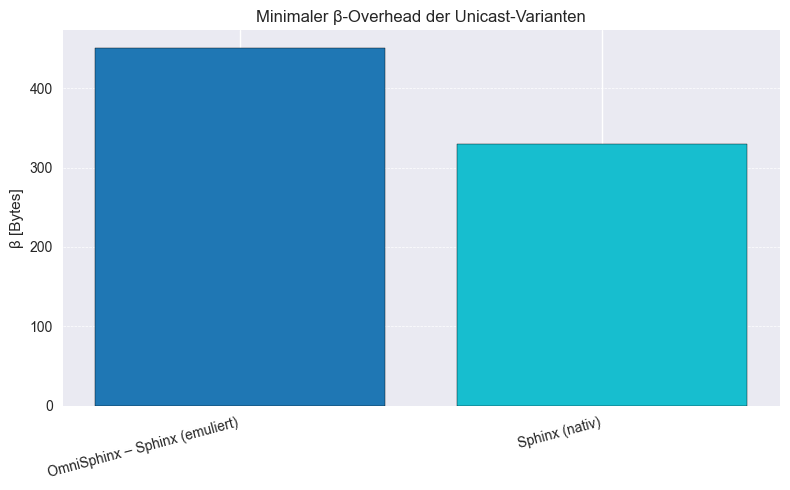

In [38]:
# Parameter
figsize = (8, 5)
title = "Minimaler β-Overhead der Unicast-Varianten"
y_label = "β [Bytes]"


positions = np.arange(len(unicast_metrics_df))
fig, ax = plt.subplots(figsize=figsize)
ax.bar(
    positions,
    unicast_metrics_df["β [B]"],
    color=[unicast_color_map[var] for var in unicast_metrics_df["Variante"]],
    edgecolor="black",
)
ax.set_title(title)
ax.set_ylabel(y_label)
ax.set_xticks(positions)
ax.set_xticklabels(unicast_metrics_df["Variante"], rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.show()


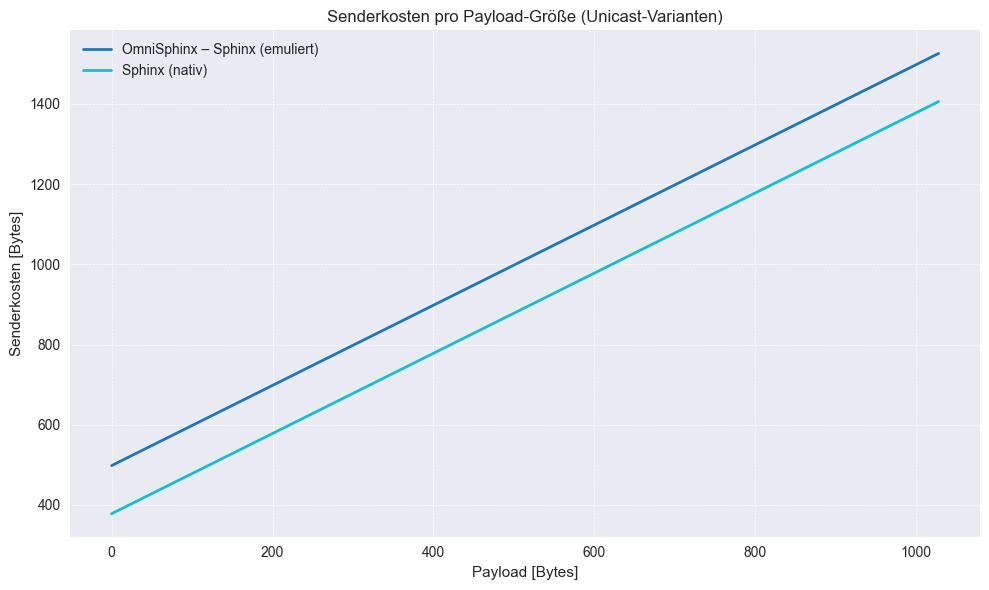

In [39]:
# Parameter
figsize = (10, 6)
title = "Senderkosten pro Payload-Größe (Unicast-Varianten)"
x_label = "Payload [Bytes]"
y_label = "Senderkosten [Bytes]"
max_payload_plot_bytes = None  # z. B. 4096, None zeigt alle Payload-Größen

plot_df = unicast_payload_metrics_df
if max_payload_plot_bytes is not None:
    plot_df = unicast_payload_metrics_df[
        unicast_payload_metrics_df["Payload [B]"] <= max_payload_plot_bytes
    ]

fig, ax = plt.subplots(figsize=figsize)
for variant_name, group in plot_df.groupby("Variante"):
    sorted_group = group.sort_values("Payload [B]")
    ax.plot(
        sorted_group["Payload [B]"],
        sorted_group["Senderkosten [B]"],
        label=variant_name,
        color=unicast_color_map[variant_name],
        linewidth=2,
    )
ax.set_title(title)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


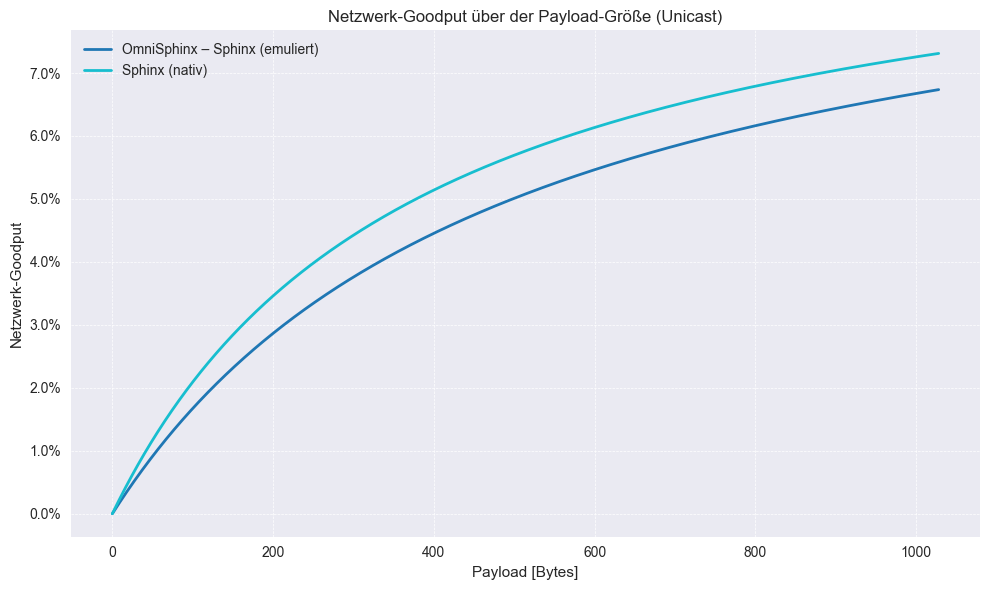

In [40]:
# Parameter
figsize = (10, 6)
title = "Netzwerk-Goodput über der Payload-Größe (Unicast)"
x_label = "Payload [Bytes]"
y_label = "Netzwerk-Goodput"
max_payload_plot_bytes = None 

plot_df = unicast_payload_metrics_df
if max_payload_plot_bytes is not None:
    plot_df = unicast_payload_metrics_df[
        unicast_payload_metrics_df["Payload [B]"] <= max_payload_plot_bytes
    ]

fig, ax = plt.subplots(figsize=figsize)
for variant_name, group in plot_df.groupby("Variante"):
    sorted_group = group.sort_values("Payload [B]")
    ax.plot(
        sorted_group["Payload [B]"],
        sorted_group["Netzwerk-Goodput"],
        label=variant_name,
        color=unicast_color_map[variant_name],
        linewidth=2,
    )
ax.set_title(title)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


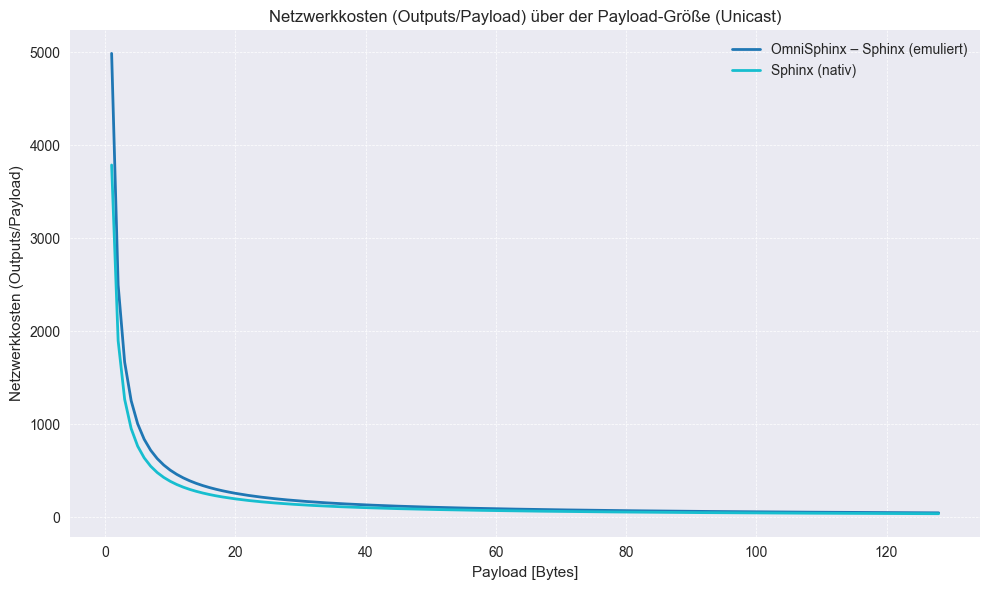

In [41]:
# Parameter
figsize = (10, 6)
title = "Netzwerkkosten (Outputs/Payload) über der Payload-Größe (Unicast)"
x_label = "Payload [Bytes]"
y_label = "Netzwerkkosten (Outputs/Payload)"
max_payload_plot_bytes = 128 

plot_df = unicast_payload_metrics_df
if max_payload_plot_bytes is not None:
    plot_df = unicast_payload_metrics_df[
        unicast_payload_metrics_df["Payload [B]"] <= max_payload_plot_bytes
    ]

fig, ax = plt.subplots(figsize=figsize)
for variant_name, group in plot_df.groupby("Variante"):
    sorted_group = group.dropna(subset=["Netzwerkkosten"]).sort_values("Payload [B]")
    ax.plot(
        sorted_group["Payload [B]"],
        sorted_group["Netzwerkkosten"],
        label=variant_name,
        color=unicast_color_map[variant_name],
        linewidth=2,
    )
ax.set_title(title)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


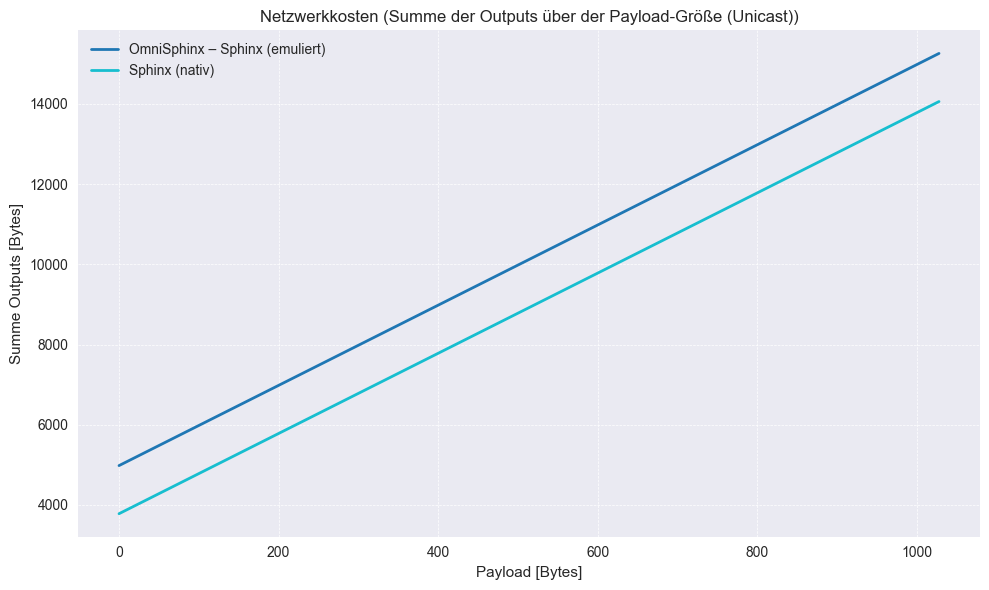

In [42]:
# Parameter
figsize = (10, 6)
title = "Netzwerkkosten (Summe der Outputs über der Payload-Größe (Unicast))"
x_label = "Payload [Bytes]"
y_label = "Summe Outputs [Bytes]"
max_payload_plot_bytes = None  # z. B. 4096, None zeigt alle Payload-Größen

plot_df = unicast_payload_metrics_df
if max_payload_plot_bytes is not None:
    plot_df = plot_df[plot_df["Payload [B]"] <= max_payload_plot_bytes]

fig, ax = plt.subplots(figsize=figsize)
for variant_name, group in plot_df.groupby("Variante"):
    sorted_group = group.sort_values("Payload [B]")
    ax.plot(
        sorted_group["Payload [B]"],
        sorted_group["Summe Outputs [B]"],
        label=variant_name,
        color=unicast_color_map[variant_name],
        linewidth=2,
    )
ax.set_title(title)
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()